In [3]:
%load_ext autoreload
%autoreload 2
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output

import sys
sys.path.append('/home/mattia/Desktop/Repos/posebench/benchmarks_3D')
from benchmark_pose import eval_colmap_model_all_scenes


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Helpers

In [4]:
def read_results(dataset, target_folder, models, thrs=[5], fillna_with_zeros=False):
    base_target = f"/home/mattia/Desktop/datasets/{dataset}"
    base_repo = "/home/mattia/Desktop/Repos/batchsfm/benchmark"
    scenes = os.listdir(base_target)

    # Read results
    dfs = {}
    for name in models:
        dfs[name] = eval_colmap_model_all_scenes(
            target_path=base_target,
            target_folder=target_folder,
            input_path=f"{base_repo}/{name}/{dataset}",
            input_folder="sparse",
            return_df=True,
            thrs=thrs,
            verbose=False
        )

    keys = sorted(list(dfs.keys()))
    for key in keys:
        dfs[key].columns = [f"{col}_{key}" if "auc" in col else col for col in dfs[key].columns]
    
    # Read timings
    total_timings = {}
    for model in models:
        if model not in total_timings:
                total_timings[f"{model}"] = {}
        for scene in scenes:
            recon_path = f"benchmark/{model}/{dataset}/{scene}"
            if not os.path.exists(recon_path):
                continue
            if scene not in total_timings[f"{model}"]:
                total_timings[f"{model}"][scene] = None
                try:
                    with open(f"{recon_path}/sparse/timings.txt", "r") as f:
                        lines = f.readlines()
                    total_timings[f"{model}"][scene] = float(lines[-1].split()[1])
                except FileNotFoundError:
                    
                    total_timings[f"{model}"][scene] = None

    df = pd.concat([dfs[key][f'auc@5_{key}'] for key in keys], axis=1)
    if fillna_with_zeros:
        df.fillna(0, inplace=True)

    df = pd.concat([df, pd.DataFrame(total_timings)], axis=1)
    # df.dropna(inplace=True) 
    df.loc['mean'] = df.mean()
    df = df.round(2)

    # clean up cell prints
    clear_output()
    print("Results:")
    display(df)

    return df

models = ["vggt", "vggt_ba", "vggt_edge"]

In [5]:
def print_average_timings(df, models):
    # print average timings
    print("Average total inference time (s):")
    for model in models:
        mean_time = df[model].mean() 
        if "edge" in model:
            mean_time += df['vggt'].mean() 
        # print at same col
        print(f"{model}: {mean_time:.2f} s")



In [6]:
def plot_auc5(df):
    df_auc = df[[col for col in df.columns if 'auc@5' in col]]
    # remove auc5 from cols names
    df_auc.columns = [col.replace('auc@5_', '') for col in df_auc.columns]

    print(df_auc.loc['mean'])
    df_auc.plot(kind='bar', figsize=(len(df_auc)//1.25, 4))
    plt.title('AUC@5 (shared camera for all)')
    # legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

In [7]:
.

SyntaxError: invalid syntax (1933637684.py, line 1)

## ETH3D

In [ ]:
df = read_results("eth3d", "sparse", models, fillna_with_zeros=False)

Results:


,auc@5_vggt,auc@5_vggt_ba,auc@5_vggt_edge,vggt,vggt_ba,vggt_edge
botanical_garden,4.20,NaN,4.32,6.84,NaN,3.65
boulders,6.35,NaN,7.17,5.11,NaN,2.45
bridge,14.54,NaN,12.84,29.06,NaN,19.34
courtyard,49.53,80.47,51.16,7.44,33.37,3.44
delivery_area,14.65,NaN,17.39,9.27,NaN,4.03
door,57.58,84.59,59.01,2.56,12.82,0.99
electro,35.04,68.83,31.73,9.67,30.86,3.49
exhibition_hall,0.62,NaN,0.94,14.77,NaN,6.71
facade,46.57,NaN,43.56,18.81,NaN,19.05
kicker,55.42,79.54,54.57,6.16,25.52,3.21


In [ ]:
print_average_timings(df, models)

Average total inference time (s):
vggt: 7.91 s
vggt_ba: 17.51 s
vggt_edge: 12.32 s


vggt         71.56
vggt_ba      85.58
vggt_edge    71.79
Name: mean, dtype: float64


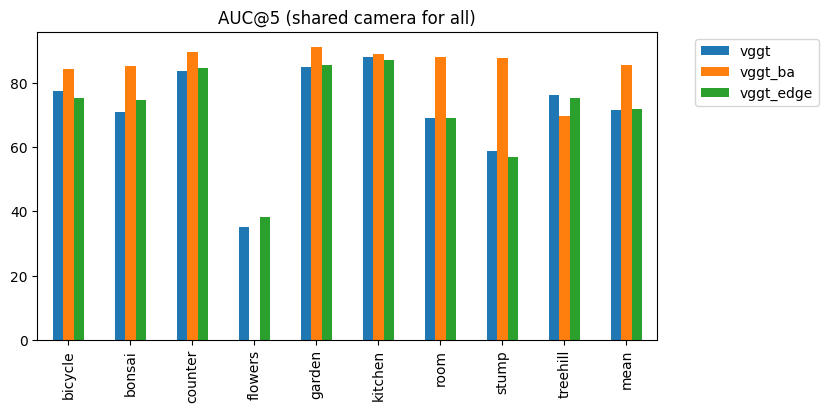

In [ ]:
plot_auc5(df)

## 7Scenes

In [ ]:
df = read_results("7scenes", "colmap/sparse", models, fillna_with_zeros=False)

Results:


,auc@5_vggt,auc@5_vggt_ba,auc@5_vggt_edge,vggt,vggt_ba,vggt_edge
chess_seq_03,38.01,39.40,39.45,39.15,199.41,62.01
chess_seq_05,41.01,43.90,43.18,37.08,193.77,26.24
fire_seq_03,47.57,47.97,51.46,37.44,157.09,61.79
fire_seq_04,39.20,43.19,44.03,37.44,216.10,59.98
heads_seq_01,55.00,62.86,57.14,37.01,133.05,85.85
office_seq_02,10.76,10.51,11.86,36.94,135.21,32.11
office_seq_06,10.85,NaN,15.59,36.98,NaN,21.15
office_seq_07,9.67,12.04,12.07,37.03,140.61,26.34
office_seq_09,14.81,NaN,15.47,37.00,NaN,27.18
pumpkin_seq_01,14.41,13.61,16.04,36.85,126.19,31.51


In [ ]:
print_average_timings(df, models)

Average total inference time (s):
vggt: 37.20 s
vggt_ba: 177.02 s
vggt_edge: 85.65 s


vggt         23.37
vggt_ba      26.72
vggt_edge    26.15
Name: mean, dtype: float64


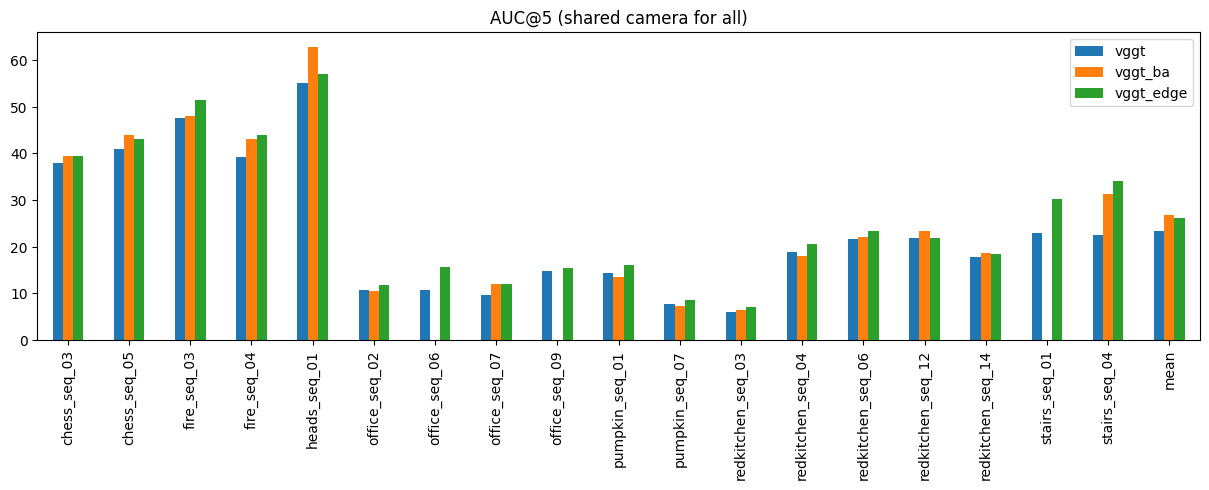

In [ ]:
plot_auc5(df)

## Mip-NeRF360

In [8]:
df = read_results("mipnerf360", "sparse_150", models, fillna_with_zeros=False)

Results:


,auc@5_vggt,auc@5_vggt_ba,auc@5_vggt_edge,vggt,vggt_ba,vggt_edge
bicycle,77.52,84.16,75.61,38.78,109.69,19.78
bonsai,70.75,85.36,72.93,36.33,142.55,17.39
counter,83.64,89.58,82.94,37.33,162.10,17.71
flowers,35.11,NaN,32.91,35.83,NaN,17.74
garden,84.90,91.25,84.59,37.30,107.44,38.72
kitchen,87.99,89.01,80.43,36.86,168.32,71.20
room,69.13,87.97,67.45,37.39,161.88,17.78
stump,58.75,87.78,56.27,27.21,108.67,5.23
treehill,76.29,69.55,70.95,34.17,88.20,9.49
mean,71.56,85.58,69.34,35.69,131.11,23.89


In [9]:
print_average_timings(df, models)

Average total inference time (s):
vggt: 35.69 s
vggt_ba: 131.11 s
vggt_edge: 59.58 s


vggt         71.56
vggt_ba      85.58
vggt_edge    69.34
Name: mean, dtype: float64


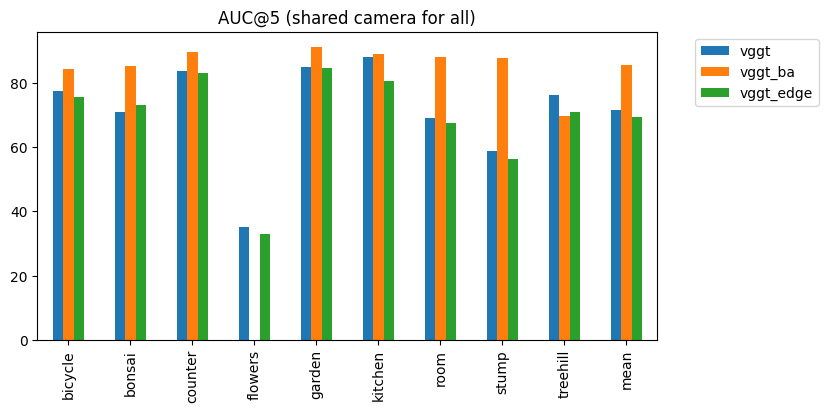

In [10]:
plot_auc5(df)

## TerraSky3D Test set